In [1]:
!pip install adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.2 MB/s eta 0:00:003.2 MB/s eta 0:00:01


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2026-03-16 09:50:59.998751: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 09:51:00.122383: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773634860.167105    5142 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773634860.180548    5142 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773634860.278171    5142 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [5]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/home/admin1/anaconda3/lib/python3.9/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-03-16 09:51:24.852083: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8768 - loss: 0.4252
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9636 - loss: 0.1238
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9757 - loss: 0.0808
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9832 - loss: 0.0576
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9856 - loss: 0.0456


In [11]:
loss, acc = model.evaluate(x_test, y_test)

print("Model Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - accuracy: 0.9686 - loss: 0.0926
Model Accuracy: 0.9750000238418579


In [13]:
epsilon = 0.1

x = tf.convert_to_tensor(x_test[:1])

with tf.GradientTape() as tape:
    tape.watch(x)
    prediction = model(x)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_test[:1], prediction)

gradient = tape.gradient(loss, x)

signed_grad = tf.sign(gradient)

adversarial_example = x + epsilon * signed_grad

In [15]:
print("Original Prediction:", np.argmax(model.predict(x)))
print("Adversarial Prediction:", np.argmax(model.predict(adversarial_example)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Original Prediction: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Adversarial Prediction: 3


In [17]:
x_adv = x_train + 0.1 * np.sign(np.random.randn(*x_train.shape))

model.fit(
    np.concatenate([x_train, x_adv]),
    np.concatenate([y_train, y_train]),
    epochs=3
)

Epoch 1/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9863 - loss: 0.0409
Epoch 2/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9939 - loss: 0.0204
Epoch 3/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9953 - loss: 0.0150


In [19]:
from cryptography.fernet import Fernet

key = Fernet.generate_key()
cipher = Fernet(key)

data = str(x_train[0]).encode()

encrypted = cipher.encrypt(data)
decrypted = cipher.decrypt(encrypted)

print("Encrypted Data:", encrypted[:60])

Encrypted Data: b'gAAAAABpt4WakieZ6lX5RLXDwvd8PfgF4ziXCJrDeJsabYh4RqsudiOlXauc'


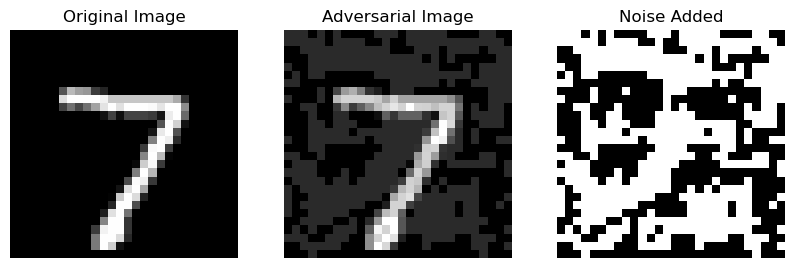

In [21]:
import matplotlib.pyplot as plt

# Convert tensors to numpy
original = x.numpy()[0]
adversarial = adversarial_example.numpy()[0]

# Plot images
plt.figure(figsize=(10,4))

# Original image
plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(original, cmap='gray')
plt.axis('off')

# Adversarial image
plt.subplot(1,3,2)
plt.title("Adversarial Image")
plt.imshow(adversarial, cmap='gray')
plt.axis('off')

# Difference
plt.subplot(1,3,3)
plt.title("Noise Added")
plt.imshow(adversarial-original, cmap='gray')
plt.axis('off')

plt.show()